Business Problem:

 The market research team at AeroFit wants to identify the characteristics of the target audience for each type of treadmill offered by the
 company, to provide a better recommendation of the treadmills to the new customers. The team decides to investigate whether there are
 differences across the product with respect to customer characteristics

# 1.EDA

In [ ]:
 import numpy as np
 import pandas as pd
 import matplotlib.pyplot as plt
 import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Sriram_datasets/Jamboree_Admission.csv")
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


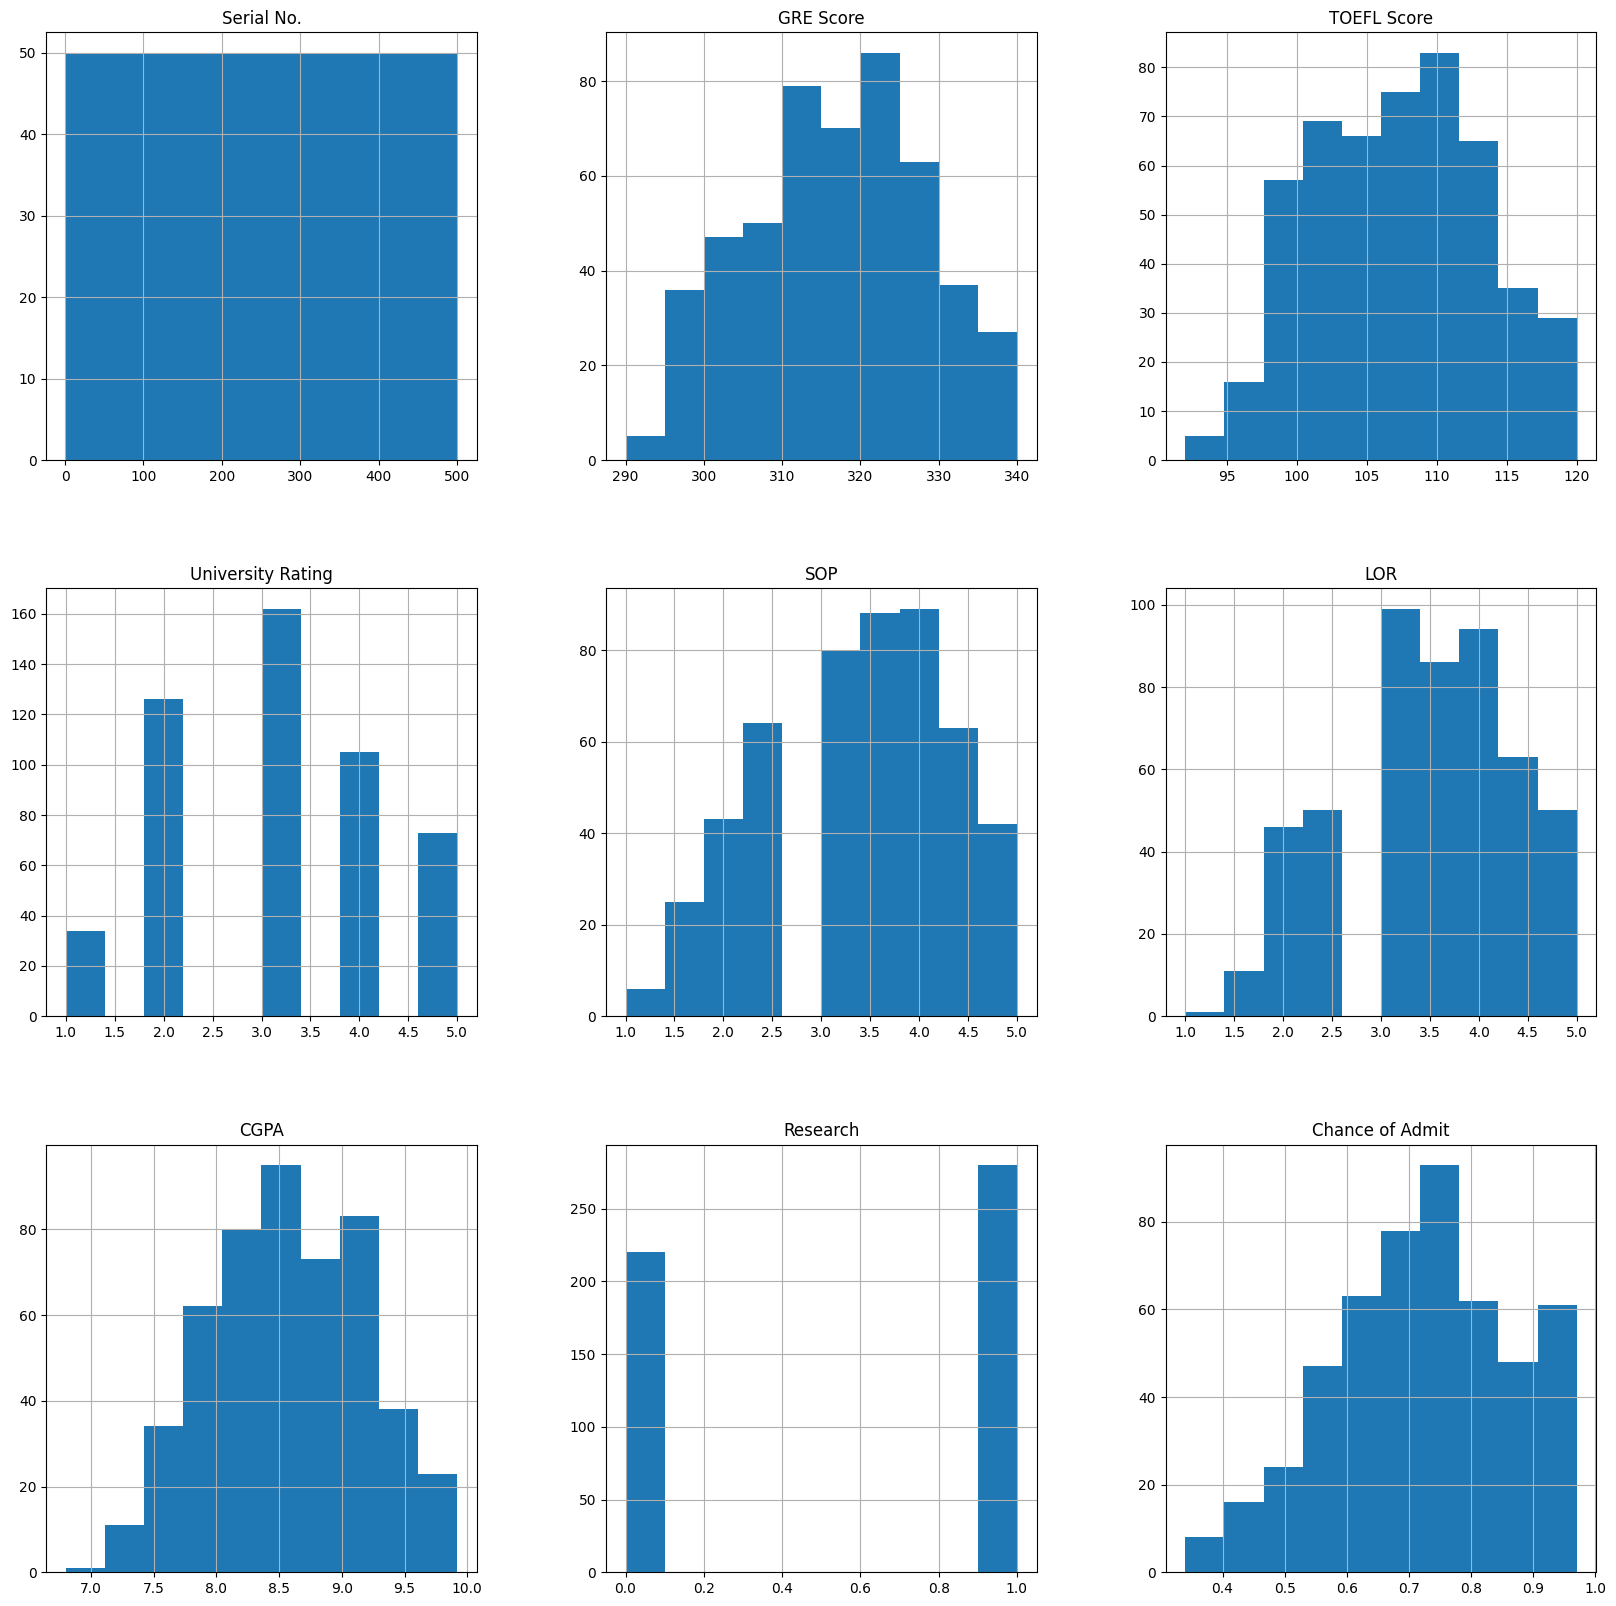

In [ ]:
 #df = df.drop_duplicates(subset='Serial No.')
 df.hist(figsize = (20,20))
 plt.show()

In [ ]:
 print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB
None


In [ ]:
 df.describe(include = 'all')

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000
mean,250.500000,316.472000,107.192000,3.114000,3.374000,3.48400,8.576440,0.560000,0.72174
std,144.481833,11.295148,6.081868,1.143512,0.991004,0.92545,0.604813,0.496884,0.14114
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.00000,6.800000,0.000000,0.34000
25%,125.750000,308.000000,103.000000,2.000000,2.500000,3.00000,8.127500,0.000000,0.63000
50%,250.500000,317.000000,107.000000,3.000000,3.500000,3.50000,8.560000,1.000000,0.72000
75%,375.250000,325.000000,112.000000,4.000000,4.000000,4.00000,9.040000,1.000000,0.82000
max,500.000000,340.000000,120.000000,5.000000,5.000000,5.00000,9.920000,1.000000,0.97000


observations:

 1. out of 500 students ,the average gre score is 316
 2. out of 500 students ,the average toe score is 107
 3. students whose avg cgpa is 8.5 ,their avg gre and toe scores are in the range of 316 and 107 with 72% chance of admit with university
 rating 3.1

In [ ]:
 print(df.isnull().sum())

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


 There are no null null values in df.

In [ ]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR', 'CGPA', 'Research', 'Chance of Admit'],
      dtype='object')

In [ ]:
df.value_counts()

,,,,,,,,,count
Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,
1,337,118,4,4.5,4.5,9.65,1,0.92,1
330,297,96,2,2.5,1.5,7.89,0,0.43,1
343,308,106,3,3.0,3.0,8.24,0,0.58,1
342,326,110,3,3.5,3.5,8.76,1,0.79,1
341,312,107,3,3.0,3.0,8.46,1,0.75,1
...,...,...,...,...,...,...,...,...,...
162,298,99,1,1.5,3.0,7.46,0,0.53,1
161,315,103,1,1.5,2.0,7.86,0,0.57,1
160,297,100,1,1.5,2.0,7.90,0,0.52,1


In [ ]:
 df['SOP'].value_counts()

,count
SOP,
4.0,89
3.5,88
3.0,80
2.5,64
4.5,63
2.0,43
5.0,42
1.5,25
1.0,6


In [ ]:
numerical_features = [feature for feature in df.columns if df[feature].dtypes!='o']
print('Number of numerical variables: ', len(numerical_features)) # This line was incorrectly indented
# visualise the numerical variables
df[numerical_features].head()

Number of numerical variables:  9


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


 In this dataset all are numerical features

# Univariate Analysis

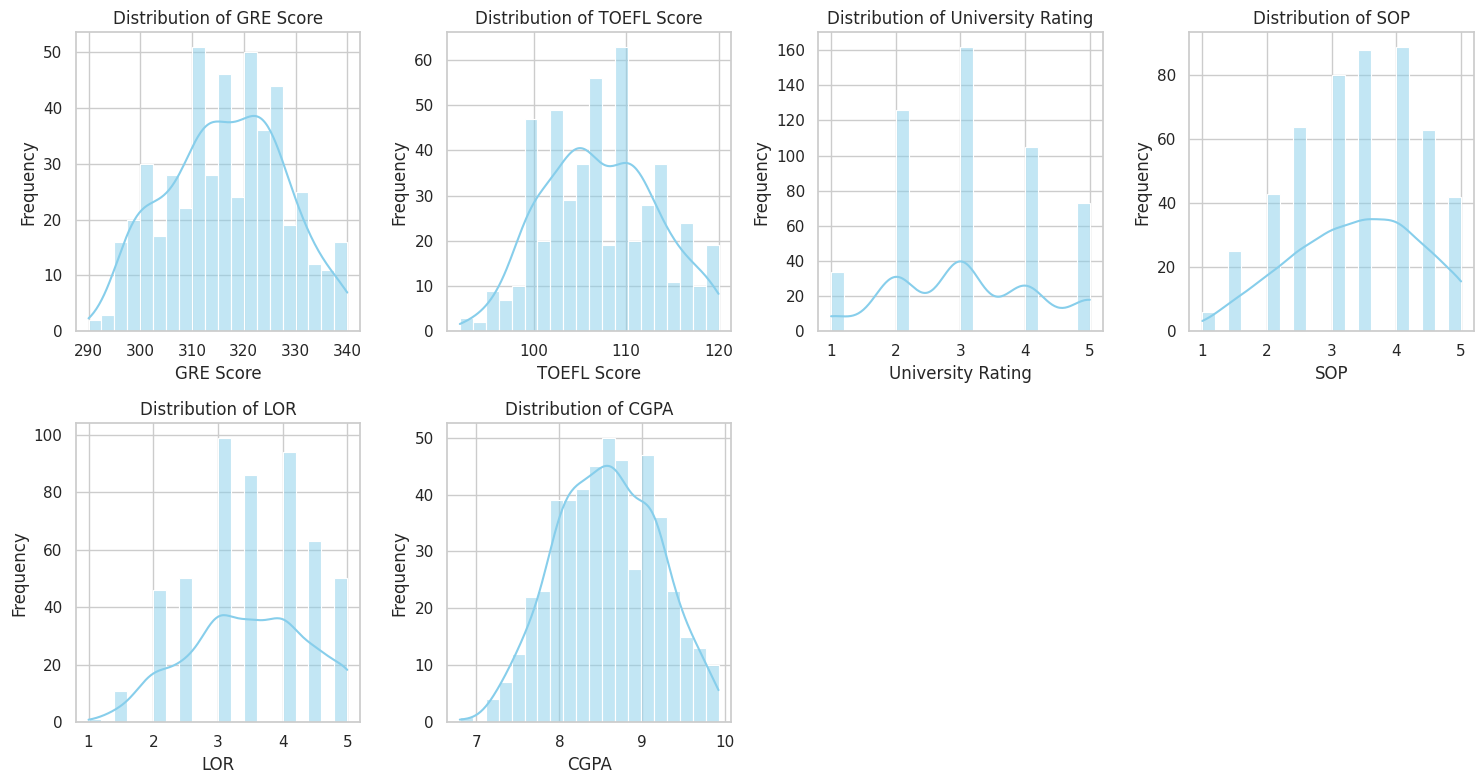

<ipython-input-19-ffe20013249d>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Research', data=df, palette='viridis')


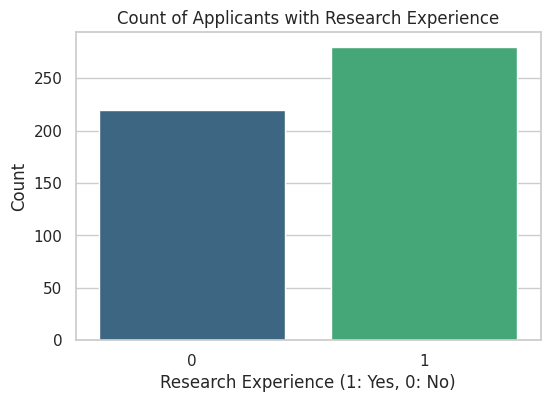

In [ ]:
# Import necessary libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns
# Set the style for better visualization
sns.set(style="whitegrid")
# Define continuous and categorical variables
# Removed the extra space after 'LOR'
continuous_vars = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA']
categorical_vars = ['Research']
# Univariate analysis - Distribution plots for continuous variables
plt.figure(figsize=(15, 8))
for i, var in enumerate(continuous_vars, 1):  # for index, value in enumerate(fruits, start=1)
    plt.subplot(2, 4, i)
    sns.histplot(df[var], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution of {var}')
    plt.xlabel(var)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()
# Univariate analysis - Barplot for categorical variables
plt.figure(figsize=(6, 4))
sns.countplot(x='Research', data=df, palette='viridis')
plt.title('Count of Applicants with Research Experience')
plt.xlabel('Research Experience (1: Yes, 0: No)')
plt.ylabel('Count')
plt.show()

 observations:

 1.All plots are normally distributed data with less skewness.

 2.out of 340 gre score ,50-55 students secured score bt 310 to 320.

 3.out of 120 toe score,more then 60 students secured score 110.

 4.Around 160 students got admission with university rating 3.

 5.>80 students whose sop in range 3.5 to 4 .

 6.cgpa-8 to 9 had perfect uniform dist.

 7.>250 students having research experience

# Bivariate Analysis

<Axes: xlabel='GRE Score', ylabel='TOEFL Score'>

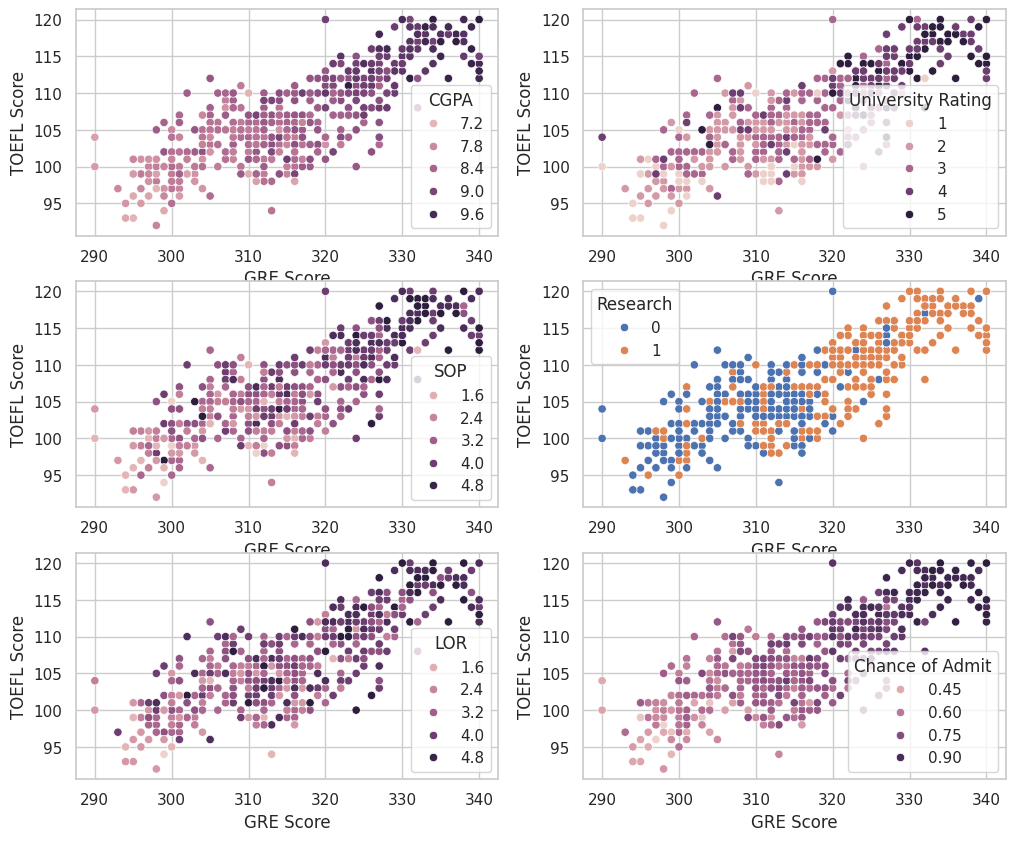

In [25]:
fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(12,10))
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="CGPA",ax=axs[0,0])
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="University Rating",ax=axs[0,1])
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="SOP",ax=axs[1,0])
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="Research",ax=axs[1,1])
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="LOR",ax=axs[2,0]) # Removed the extra space after 'LOR'
sns.scatterplot(data=df, x="GRE Score", y="TOEFL Score", hue="Chance of Admit",ax=axs[2,1]) # Removed the extra space after 'Admit'

Observations from scatter plot:

 1.Gre and toe scores follows perfect positive correlation.

 2.For a student both gre and toe scores are in top range.

 3.Students having high cgpa,sop,research exposure along with high gre and toe scores are having high chances to admit in top university
 rating.

 4.students who secured toe score>105 and gre score>320 having high chance of admit

<Axes: xlabel='University Rating', ylabel='GRE Score'>

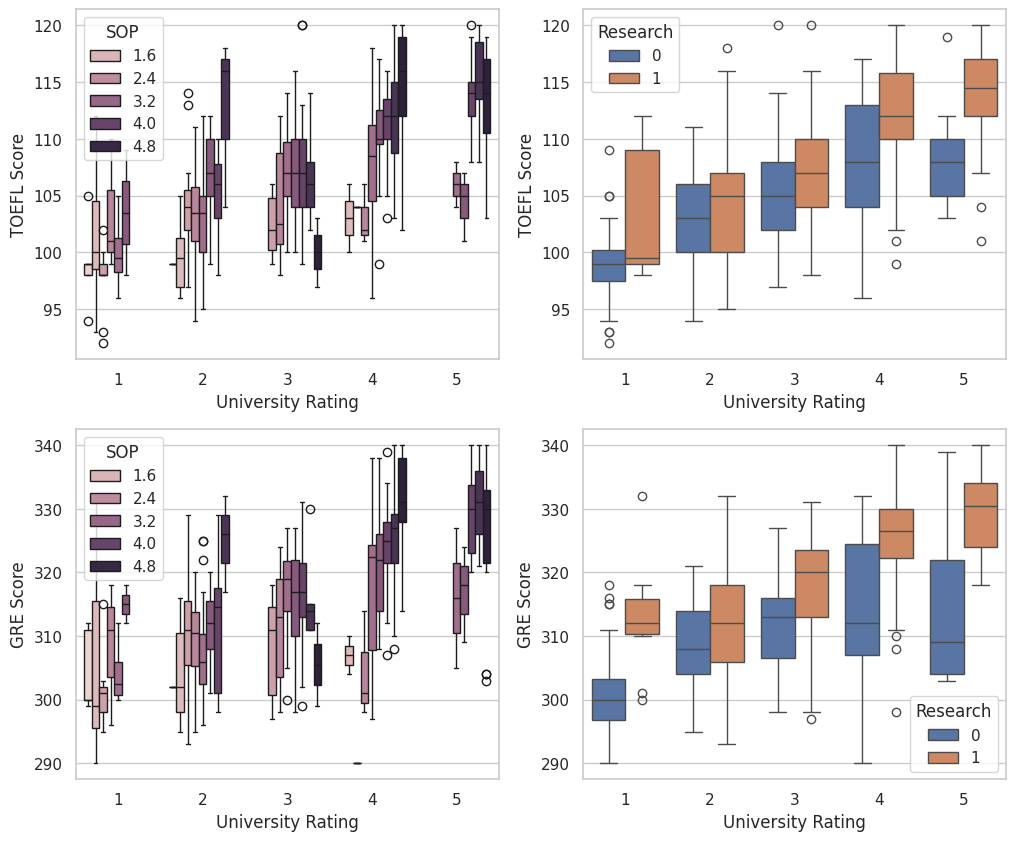

In [28]:
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12,10))
sns.boxplot(x='University Rating', y='TOEFL Score', data=df,hue='SOP',ax=axs[0,0])
sns.boxplot(x='University Rating', y='TOEFL Score', data=df,hue='Research',ax=axs[0,1])
sns.boxplot(x='University Rating', y='GRE Score', data=df,hue='SOP',ax=axs[1,0])
sns.boxplot(x='University Rating', y='GRE Score', data=df,hue='Research',ax=axs[1,1])

Observations from box plot:

 1.students with toe score>110 with sop rating 5, having high chance of getting admission with university ratings 4 and 5.

 2.students with toe score>110 having high research exposure

 3.students with gre score>320 with sop rating 5, having high chance of getting admission with university ratings 4 and 5.

 4.students with gre score>320 having high research exposure

# Multivariate Analysis

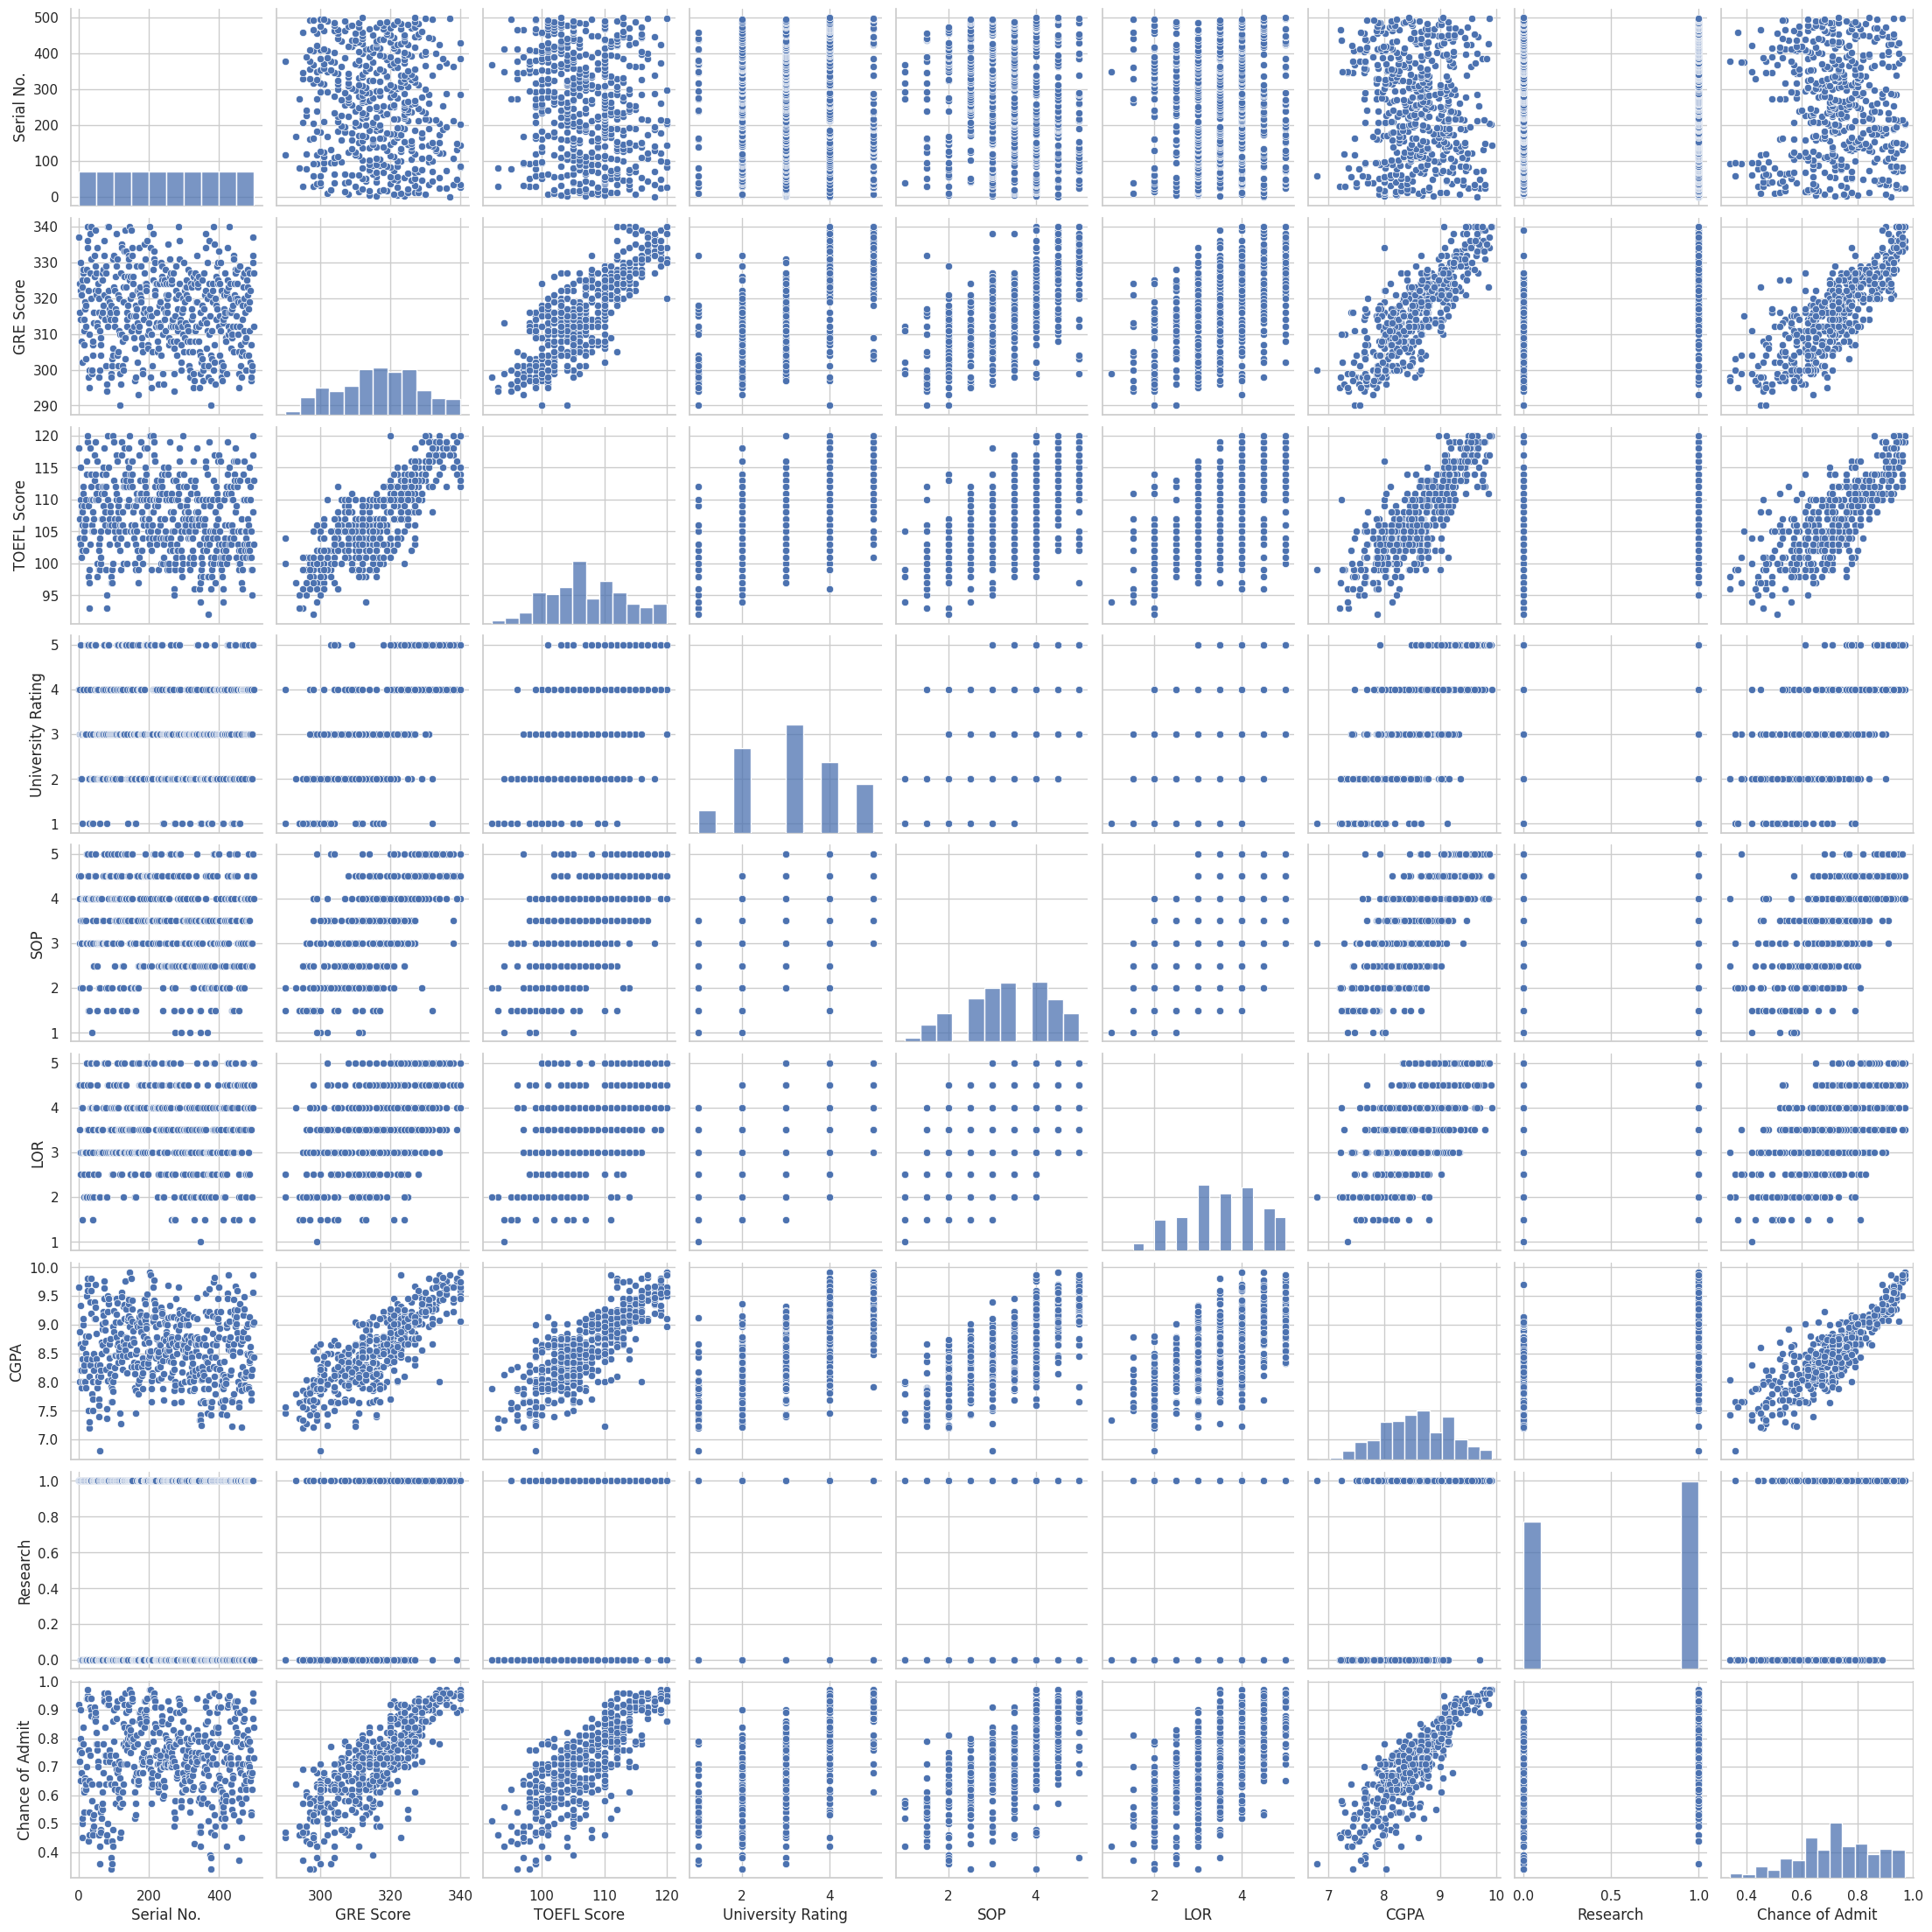

In [29]:
sns.pairplot(df)

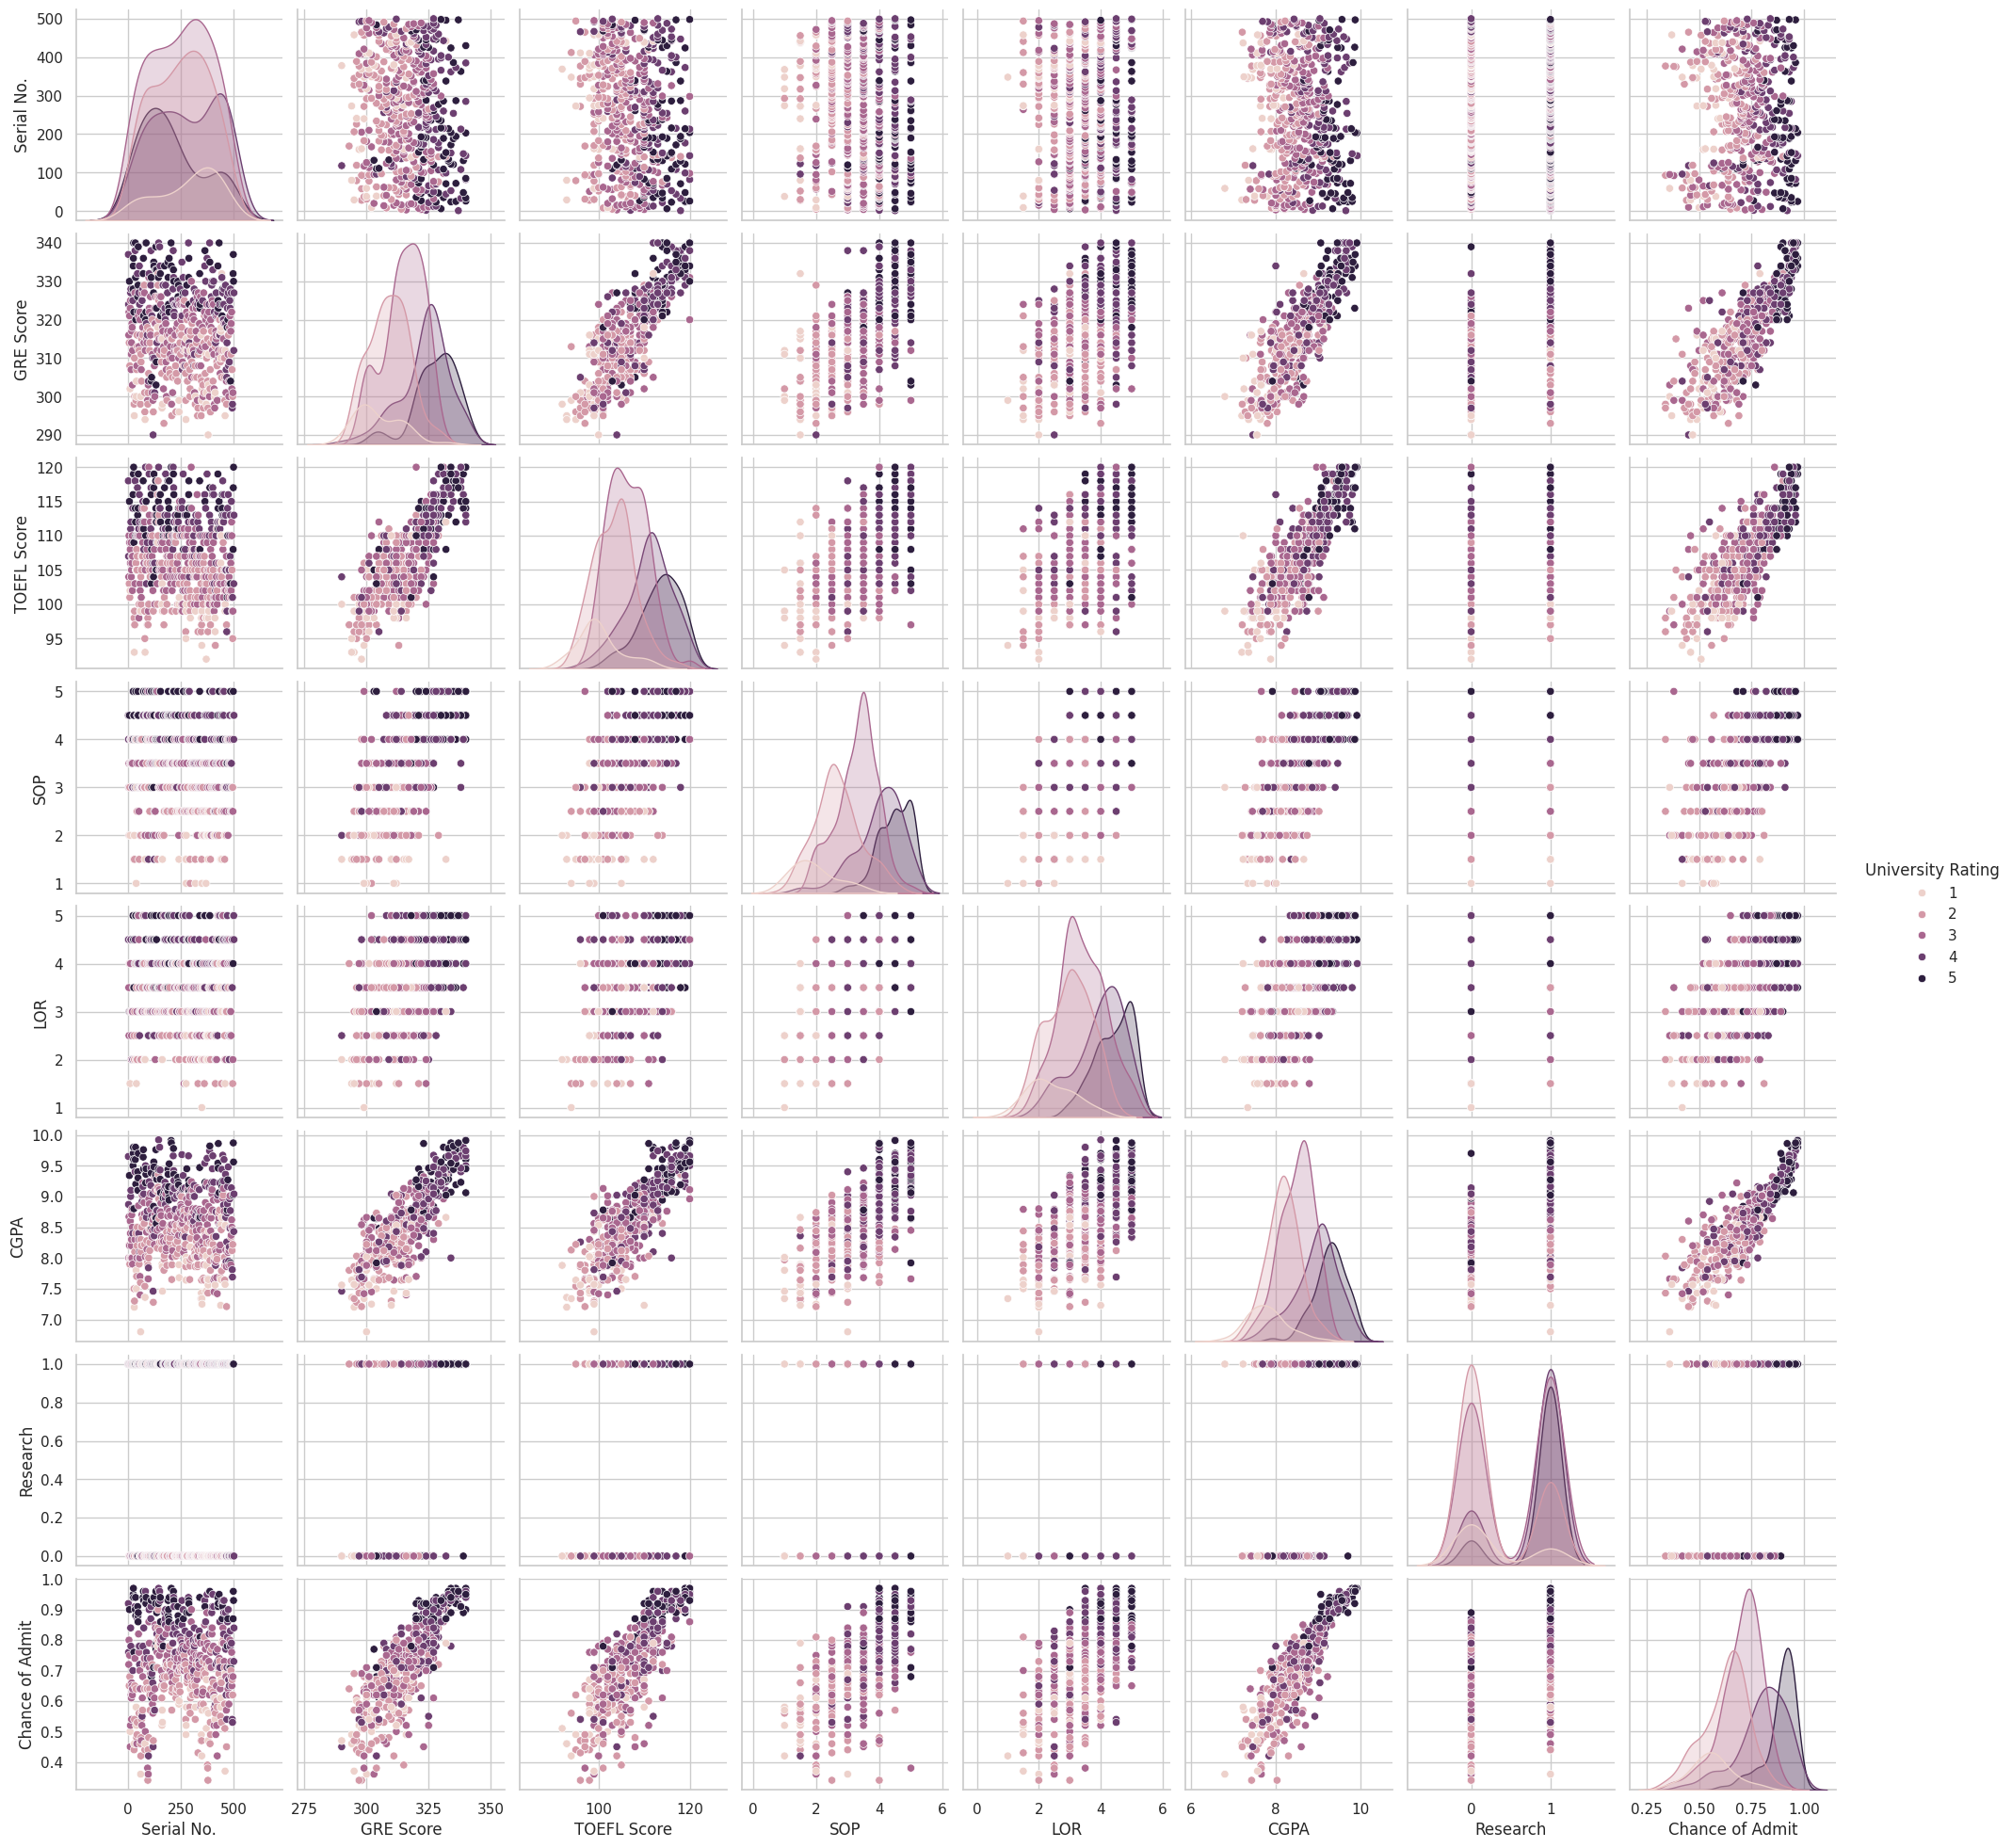

In [30]:
 sns.pairplot(df,hue="University Rating")

<Axes: >

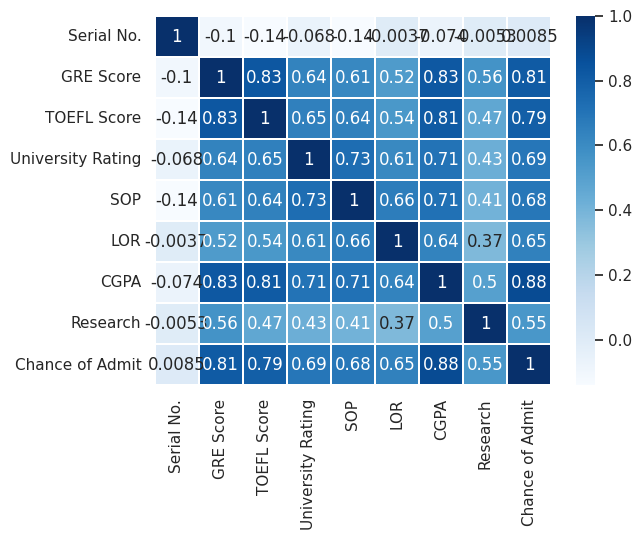

In [31]:
 sns.heatmap(df.corr(), annot=True, cmap="Blues",linewidth=.1 )

 observations:

 1.Toe and gre scores having high corr coef = 0.83
 we can observe the variation in correlation coe cients wrt different features comparisions.

 2.grescore vs chance of admit having high corr coef = 0.81

 3.cgpa vs chance of admit having high corr coef = 0.88

# 2.Data Pre-Processing

In [33]:
 # Duplicate value check
 duplicate_rows = df[df.duplicated()]
 print("Number of duplicate rows:", duplicate_rows.shape[0])
 # Drop duplicate rows
 df = df.drop_duplicates()

 # Check for missing values
 missing_values = df.isnull().sum()
 print("Missing Values:\n", missing_values)

Number of duplicate rows: 0
Missing Values:
 Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


 There are no missing values in df

q1 q3 iqr: 308.0 325.0 17.0
lower_limit,upper_limit: 282.5 350.5
before removing outliers: 500
after removing outliers: 500
num of outliers: 0
     Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR  CGPA  \
0             1      337.0          118                  4  4.5  4.5  9.65   
1             2      324.0          107                  4  4.0  4.5  8.87   
2             3      316.0          104                  3  3.0  3.5  8.00   
3             4      322.0          110                  3  3.5  2.5  8.67   
4             5      314.0          103                  2  2.0  3.0  8.21   
..          ...        ...          ...                ...  ...  ...   ...   
495         496      332.0          108                  5  4.5  4.0  9.02   
496         497      337.0          117                  5  5.0  5.0  9.87   
497         498      330.0          120                  5  4.5  5.0  9.56   
498         499      312.0          103                  4  4.0  5.0  8.43   

<ipython-input-34-1209a9cd4d93>:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '350.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  new_df.loc[(new_df['GRE Score'] > upper_limit), 'GRE Score'] = upper_limit


<Axes: ylabel='GRE Score'>

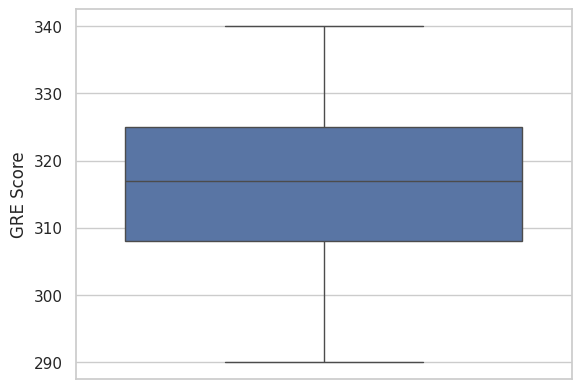

In [34]:
 # Outlier detection by IQR method
 q1= df['GRE Score'].quantile(0.25)
 q3= df['GRE Score'].quantile(0.75)
 iqr = q3-q1 # iqr- inter quatile range
 print('q1','q3','iqr:',q1,q3,iqr)
 lower_limit = q1 - (1.5*iqr)
 upper_limit = q3 + (1.5*iqr)
 print('lower_limit' ',' 'upper_limit:', lower_limit, upper_limit)
 #trimming - delete outlier data
 new_df = df.loc[(df['GRE Score'] < upper_limit) & (df['GRE Score'] > lower_limit)]
 print('before removing outliers:', len(df))
 print('after removing outliers:', len(new_df))
 print('num of outliers:',len(df)-len(new_df))
 #capping - upper,lower limit
 new_df.loc[(new_df['GRE Score'] > upper_limit), 'GRE Score'] = upper_limit
 new_df.loc[(new_df['GRE Score'] < lower_limit), 'GRE Score'] = lower_limit
 print(new_df)
 sns.boxplot(new_df['GRE Score'])

 As there are no outliers in the data ,after performing IQR outlier detection method we can see no of outliers is 0

In [36]:
 # Feature engineering - Creating a new feature (e.g., Total Scores)
 df['Total Scores'] = df['GRE Score'] + df['TOEFL Score']
 df.head()
 # Dropping unnecessary columns
 df = df.drop(['Serial No.'], axis=1, errors='ignore')
 df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Total Scores
0,337,118,4,4.5,4.5,9.65,1,0.92,455
1,324,107,4,4.0,4.5,8.87,1,0.76,431
2,316,104,3,3.0,3.5,8.00,1,0.72,420
3,322,110,3,3.5,2.5,8.67,1,0.80,432
4,314,103,2,2.0,3.0,8.21,0,0.65,417
...,...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87,440
496,337,117,5,5.0,5.0,9.87,1,0.96,454
497,330,120,5,4.5,5.0,9.56,1,0.93,450
498,312,103,4,4.0,5.0,8.43,0,0.73,415


In [37]:
 df = df.to_csv("result.csv")

In [38]:
 df = pd.read_csv("result.csv")
 df.head()

,Unnamed: 0,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Total Scores
0,0,337,118,4,4.5,4.5,9.65,1,0.92,455
1,1,324,107,4,4.0,4.5,8.87,1,0.76,431
2,2,316,104,3,3.0,3.5,8.00,1,0.72,420
3,3,322,110,3,3.5,2.5,8.67,1,0.80,432
4,4,314,103,2,2.0,3.0,8.21,0,0.65,417


# 3.Model Building

In [41]:
 from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LinearRegression, Ridge, Lasso
 from sklearn.metrics import mean_squared_error
 from statsmodels.stats.outliers_influence import variance_inflation_factor
 import matplotlib.pyplot as plt
 import seaborn as sns
 import statsmodels.api as sm
 from scipy import stats
 # Data Preparation for Modeling:
 # Separate independent variables (X) and the dependent variable (y)
 X = df.drop('Chance of Admit', axis=1)
 y = df['Chance of Admit']
 X.shape, y.shape

((500, 9), (500,))

In [44]:
 # Split the dataset into training and testing sets
 from sklearn.model_selection import train_test_split
 X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 print('X_train:', X_train.shape)
 print('y_train:',y_train.shape)
 print('X_test:',X_test.shape)
 print('y_test:',y_test.shape)


X_train: (400, 9)
y_train: (400,)
X_test: (100, 9)
y_test: (100,)


In [45]:
 y_train = y_train.values.reshape(400,-1)
 y_test = y_test.values.reshape(100,-1)

 We will use

 X_train and y_train to train our model.

 X_test and y_test to evaluate the model's performance

Scaling the data

In [46]:
 from sklearn.preprocessing import MinMaxScaler
 scaler = MinMaxScaler()
 df = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
 df.head()

,Unnamed: 0,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Total Scores
0,0.000000,0.94,0.928571,0.75,0.875,0.875,0.913462,1.0,0.920635,0.931507
1,0.002004,0.68,0.535714,0.75,0.750,0.875,0.663462,1.0,0.666667,0.602740
2,0.004008,0.52,0.428571,0.50,0.500,0.625,0.384615,1.0,0.603175,0.452055
3,0.006012,0.64,0.642857,0.50,0.625,0.375,0.599359,1.0,0.730159,0.616438
4,0.008016,0.48,0.392857,0.25,0.250,0.500,0.451923,0.0,0.492063,0.410959


In [48]:
# Build and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [50]:
# Make predictions on the test set
y_pred = model.predict(X_test)

In [51]:
 # Model statistics
 from sklearn.metrics import mean_squared_error, r2_score
 mse = mean_squared_error(y_test, y_pred)
 r2 = r2_score(y_test, y_pred)
 print(f'Mean Squared Error: {mse}')
 print(f'R-squared: {r2}')

Mean Squared Error: 0.003551180545098705
R-squared: 0.8263481396039754


In [52]:
 ridge_model = Ridge(alpha=1.0)
 ridge_model.fit(X_train, y_train)
 lasso_model = Lasso(alpha=1.0)
 lasso_model.fit(X_train, y_train)


Lasso()

# 4.Testing the assumptions of the linear regression model

In [54]:
 #4.1.Multicollinearity check by VIF score
 X_sm = sm.add_constant(X_train)  # Statmodels default is without intercept, to add intercept we need to add constant.
 model = sm.OLS(y_train, X_sm)
 results = model.fit()
 # Print the summary statistics of the model
 print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     236.4
Date:                Sat, 15 Mar 2025   Prob (F-statistic):          1.20e-144
Time:                        11:12:49   Log-Likelihood:                 570.60
No. Observations:                 400   AIC:                            -1123.
Df Residuals:                     391   BIC:                            -1087.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -1.4754      0.12

In [55]:
 from sklearn.preprocessing import StandardScaler
 scaler = StandardScaler()
 X_tr_scaled = scaler.fit_transform(X_train)
 X_sm = sm.add_constant(X_tr_scaled)  #Statmodels default is without intercept, to add intercept we need to add constant
 sm_model = sm.OLS(y_train, X_sm).fit()
 print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.829
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     236.4
Date:                Sat, 15 Mar 2025   Prob (F-statistic):          1.20e-144
Time:                        11:13:06   Log-Likelihood:                 570.60
No. Observations:                 400   AIC:                            -1123.
Df Residuals:                     391   BIC:                            -1087.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.7242      0.003    246.426      0.0

In [57]:
 vif = pd.DataFrame()
 X_t = pd.DataFrame(X_tr_scaled, columns=X_train.columns)
 vif['Features'] = X_t.columns
 vif['VIF'] = [variance_inflation_factor(X_t.values, i) for i in range(X_t.shape[1])]
 vif['VIF'] = round(vif['VIF'], 2)
 vif = vif.sort_values(by = "VIF", ascending = False)
 vif

/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Features,VIF
1,GRE Score,inf
2,TOEFL Score,inf
8,Total Scores,inf
6,CGPA,4.68
4,SOP,2.82
3,University Rating,2.57
5,LOR,2.01
7,Research,1.52
0,Unnamed: 0,1.05


There is no multi collinearity in the data as we can observe that VIF<5

In [64]:
#4.2 The mean of residuals is nearly zero
# Add a constant column to X_test for prediction to match the training data
X_test_sm = sm.add_constant(X_test)
# Predict using the modified X_test and the statsmodels model (sm_model or results)
# Choose the model you want to evaluate (sm_model or results)
y_pred = results.predict(X_test_sm)  # If using the model from cell 54
# OR
#y_pred = sm_model.predict(X_test_sm) # If using the model from cell 55

# Reshape y_pred to have the same dimensions as y_test
y_pred = y_pred.values.reshape(y_test.shape)

residuals = y_test - y_pred
mean_residuals = np.mean(residuals)
print(f"Mean of Residuals: {mean_residuals}")

Mean of Residuals: -0.005711474436268695


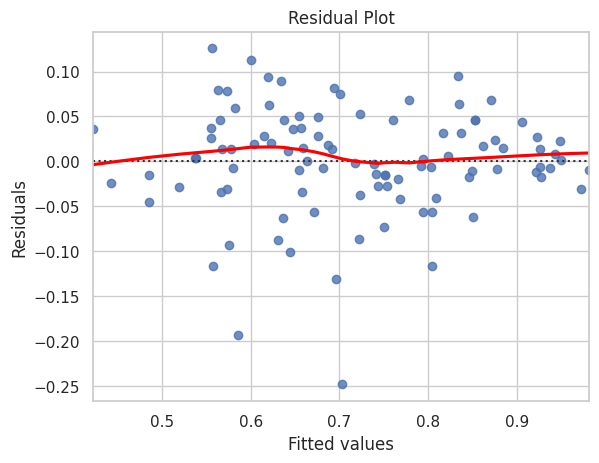

In [66]:
#4.3 Linearity of variables (no pattern in the residual plot)
sns.residplot(x=y_pred, y=residuals, lowess=True, line_kws={'color': 'red'})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

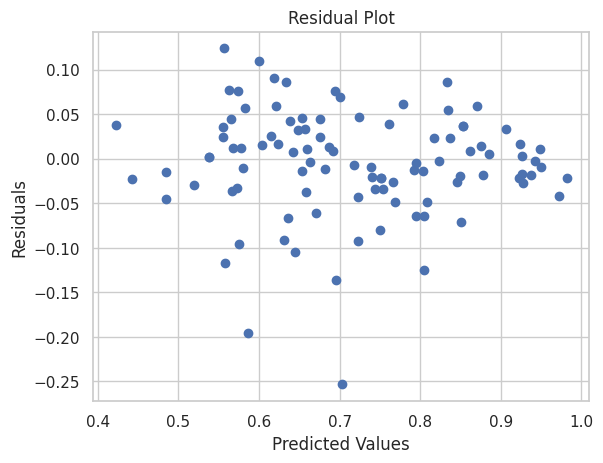

In [68]:
# 4.4 Test for Homoscedasticity
 # Plot residuals against predicted values
plt.scatter(y_pred, residuals)
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

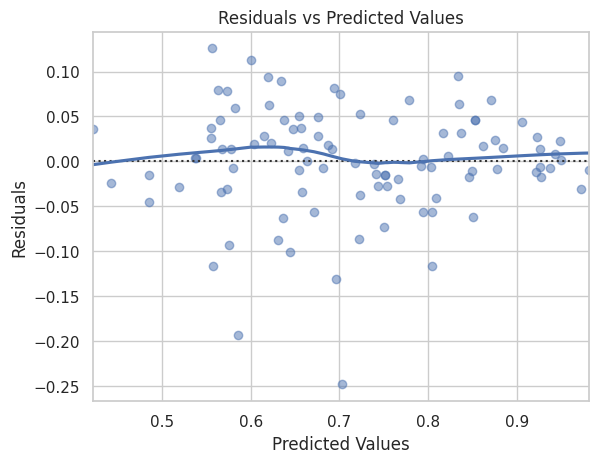

In [70]:
# Plot residuals against predicted values (or any other relevant variable)
sns.residplot(x=y_pred, y=residuals, lowess=True, scatter_kws={'alpha': 0.5})
plt.title('Residuals vs Predicted Values')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.show()

# 5.Model performance evaluation

In [73]:
# Train set predictions
from sklearn.metrics import mean_absolute_error, mean_squared_error
# Add a constant to X_train for prediction
X_train_sm = sm.add_constant(X_train)
# Predict using the modified X_train and the statsmodels model (sm_model or results)
# Choose the model you want to evaluate (sm_model or results)
#y_train_pred = model.predict(X_train_sm)  # This was causing the issue
y_train_pred = results.predict(X_train_sm)  # If using the model from cell 54
# OR
#y_train_pred = sm_model.predict(X_train_sm) # If using the model from cell 55

# Reshape y_train_pred if needed to have the same dimensions as y_train
y_train_pred = y_train_pred.values.reshape(y_train.shape)

# Test set predictions
# Add a constant to X_test for prediction
X_test_sm = sm.add_constant(X_test)
#y_test_pred = model.predict(X_test_sm)  # This was causing the issue in cell 72
# Predict using the modified X_test and the statsmodels model (sm_model or results)
# Choose the model you want to evaluate (sm_model or results)
y_test_pred = results.predict(X_test_sm)  # If using the model from cell 54
# OR
#y_test_pred = sm_model.predict(X_test_sm) # If using the model from cell 55

# Reshape y_test_pred if needed to have the same dimensions as y_test
y_test_pred = y_test_pred.values.reshape(y_test.shape)


# Metrics for the training set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)
# Metrics for the testing set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)
# Adjusted R-squared for the training set
n = len(y_train)
p = X_train.shape[1]
adj_r2_train = 1 - ((1 - train_r2) * (n - 1) / (n - p - 1))
# Adjusted R-squared for the testing set
n_test = len(y_test)
p_test = X_test.shape[1]
adj_r2_test = 1 - ((1 - test_r2) * (n_test - 1) / (n_test - p_test - 1))
# Print the metrics
print(f'Training MAE: {train_mae}')
print(f'Testing MAE: {test_mae}')
print(f'Training RMSE: {train_rmse}')
print(f'Testing RMSE: {test_rmse}')
print(f'Training R-squared: {train_r2}')
print(f'Testing R-squared: {test_r2}')
print(f'Training Adjusted R-squared: {adj_r2_train}')
print(f'Testing Adjusted R-squared: {adj_r2_test}')

Training MAE: 0.042245681471076504
Testing MAE: 0.04325885259545254
Training RMSE: 0.05810930522166972
Testing RMSE: 0.05959178252996567
Training R-squared: 0.8286710487778687
Testing R-squared: 0.8263481396039745
Training Adjusted R-squared: 0.8247173037496657
Testing Adjusted R-squared: 0.8089829535643719
